<a href="https://colab.research.google.com/github/lianbelian/TUGAS-PAK-PRAYIT-VISKOM/blob/main/JS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D1

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


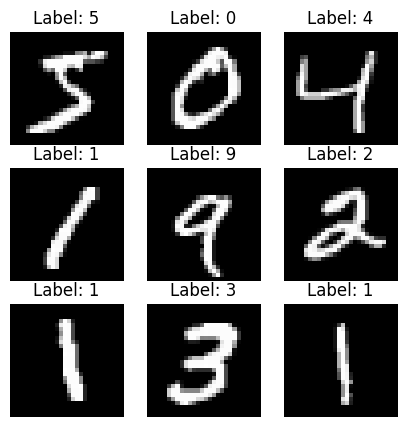

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range (9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

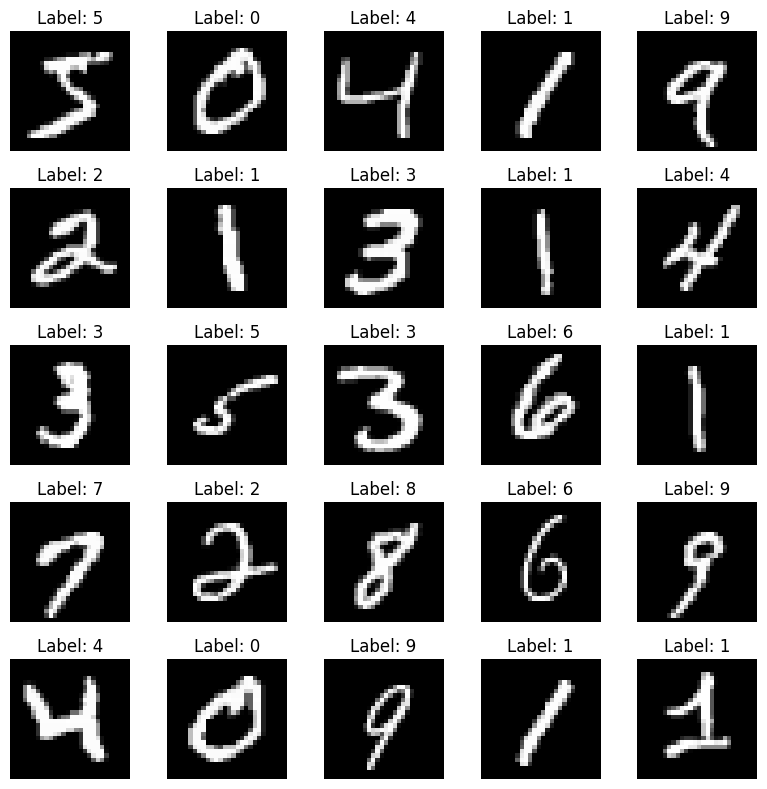

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan 25 contoh (5x5 grid)
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

D2

In [4]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat

y_pred = clf.predict(x_test_flat)
print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9101


In [5]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat

y_pred = clf.predict(x_test_flat)
print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


D3

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9475 - loss: 0.1778 - val_accuracy: 0.9798 - val_loss: 0.0688
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9821 - loss: 0.0586 - val_accuracy: 0.9860 - val_loss: 0.0499
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9876 - loss: 0.0395 - val_accuracy: 0.9858 - val_loss: 0.0492
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9912 - loss: 0.0273 - val_accuracy: 0.9867 - val_loss: 0.0492
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9880 - val_loss: 0.0519


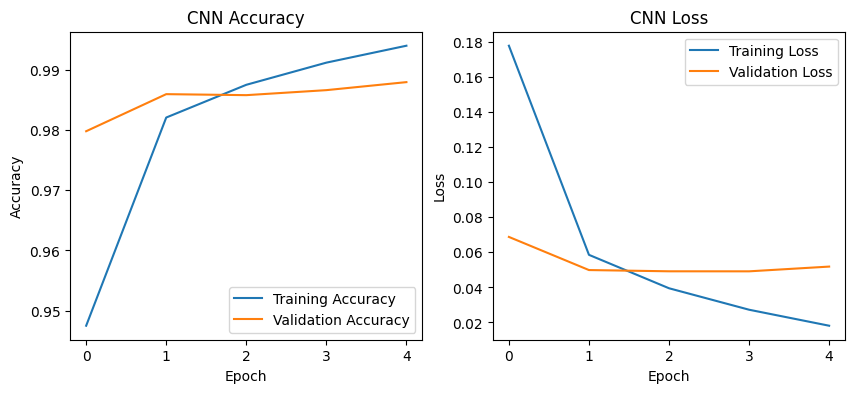

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load ulang dataset MNIST agar x_train dan x_test kembali ke format MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 30ms/step - accuracy: 0.9528 - loss: 0.1546 - val_accuracy: 0.9792 - val_loss: 0.0651
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9839 - loss: 0.0512 - val_accuracy: 0.9863 - val_loss: 0.0449
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9900 - val_loss: 0.0342
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9920 - loss: 0.0252 - val_accuracy: 0.9890 - val_loss: 0.0394
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9907 - val_loss: 0.0377


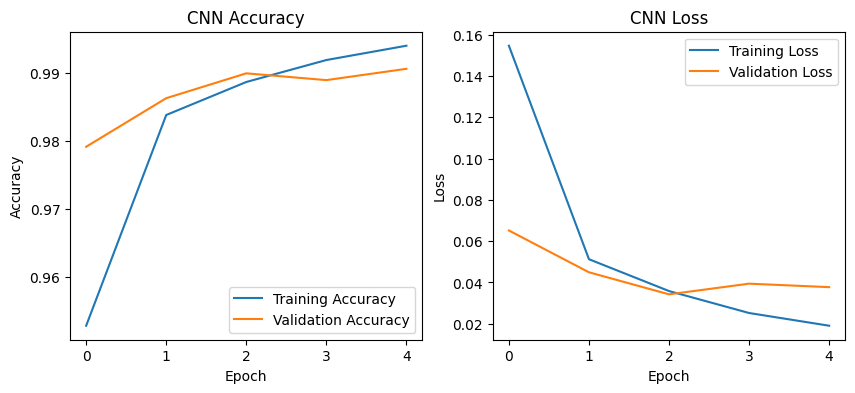

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),  # <--- Lapisan Conv2D tambahan
    layers.MaxPooling2D((2,2)),                  # <--- Opsional: MaxPooling tambahan
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

D4

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1502s 9us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.4666 - loss: 1.4712 - val_accuracy: 0.5666 - val_loss: 1.2504
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.6055 - loss: 1.1122 - val_accuracy: 0.6166 - val_loss: 1.0895
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.6522 - loss: 0.9897 - val_accuracy: 0.6416 - val_loss: 1.0355
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6820 - loss: 0.9070 - val_accuracy: 0.6426 - val_loss: 1.0431
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.7071 - loss: 0.8415 - val_accuracy: 0.6962 - val_loss: 0.8795
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 45ms/step - accuracy: 0.7282 - loss: 0.7821 - val_accuracy: 0.6974 - val_loss: 0.8955
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.7407 - loss: 0.7410 - val_accuracy: 0.6926 - val_loss: 0.8898
Epoch 8/10
1407/1407

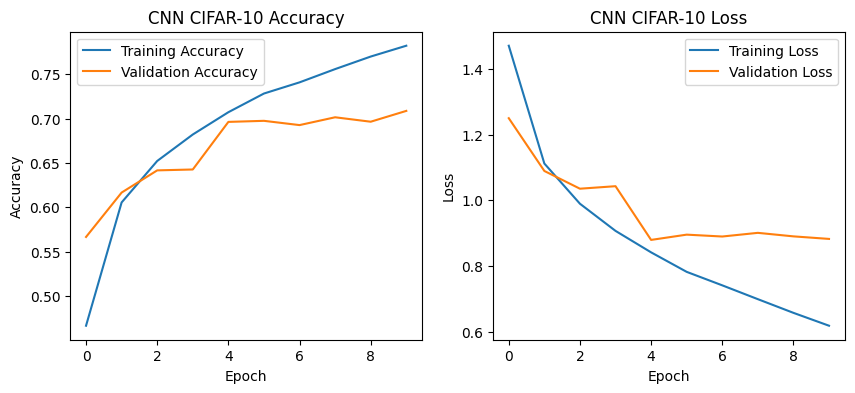

In [8]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.3116 - loss: 1.8311 - val_accuracy: 0.4700 - val_loss: 1.4555
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.4412 - loss: 1.5223 - val_accuracy: 0.5388 - val_loss: 1.2800
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.4919 - loss: 1.3906 - val_accuracy: 0.5964 - val_loss: 1.1496
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.5249 - loss: 1.3080 - val_accuracy: 0.6272 - val_loss: 1.0666
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.5470 - loss: 1.2513 - val_accuracy: 0.6320 - val_loss: 1.0737
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.5696 - loss: 1.2025 - val_accuracy: 0.6368 - val_loss: 1.0336
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.5840 - loss: 1.1573 - val_accuracy: 0.6600 - val_loss: 0.9772
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.5977 -

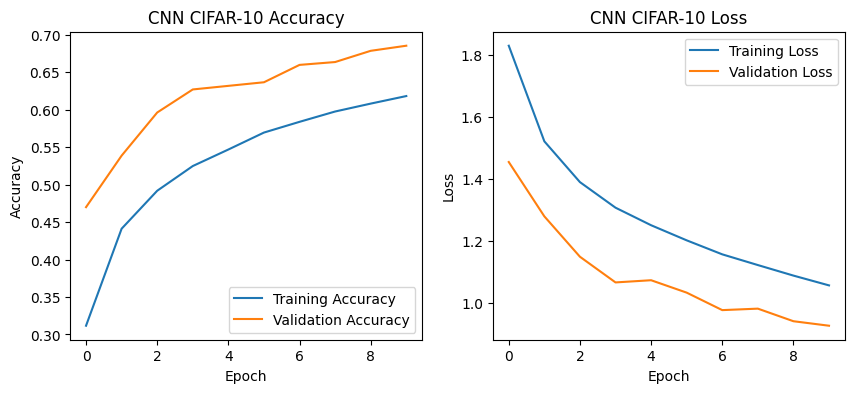

In [9]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),                  # <--- Menambahkan lapisan Dropout(0.5) di sini
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

D5

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 644s 457ms/step - accuracy: 0.5202 - loss: 1.3767 - val_accuracy: 0.5622 - val_loss: 1.2500
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 645s 458ms/step - accuracy: 0.5835 - loss: 1.1958 - val_accuracy: 0.5956 - val_loss: 1.1581
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 682s 458ms/step - accuracy: 0.6039 - loss: 1.1378 - val_accuracy: 0.5986 - val_loss: 1.1322
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 630s 447ms/step - accuracy: 0.6170 - loss: 1.0968 - val_accuracy: 0.5966 - val_loss: 1.1345
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 629s 447ms/step - accuracy: 0.6287 - loss: 1.0643 - val_accuracy: 0.6094 - val_loss: 1.1190


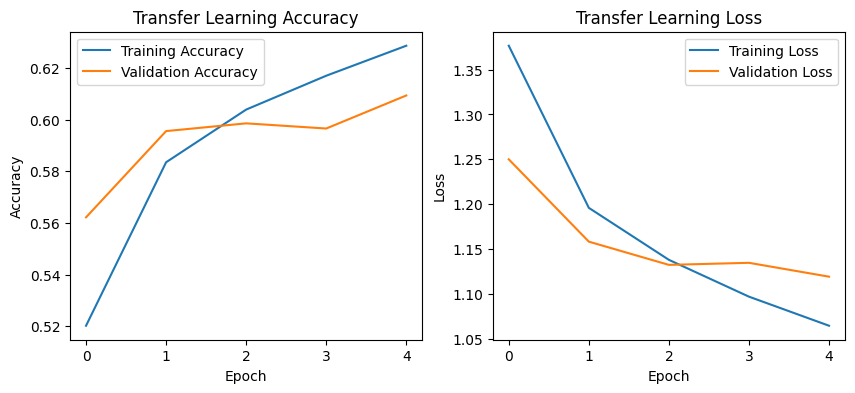

In [10]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 728s 517ms/step - accuracy: 0.5652 - loss: 1.2430 - val_accuracy: 0.6140 - val_loss: 1.0949
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 718s 511ms/step - accuracy: 0.6332 - loss: 1.0467 - val_accuracy: 0.6268 - val_loss: 1.0392
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 722s 513ms/step - accuracy: 0.6593 - loss: 0.9716 - val_accuracy: 0.6530 - val_loss: 0.9913
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 750s 519ms/step - accuracy: 0.6735 - loss: 0.9255 - val_accuracy: 0.6674 - val_loss: 0.9511
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 722s 513ms/step - accuracy: 0.6902 - loss: 0.8775 - val_accuracy: 0.6606 - val_loss: 0.9833


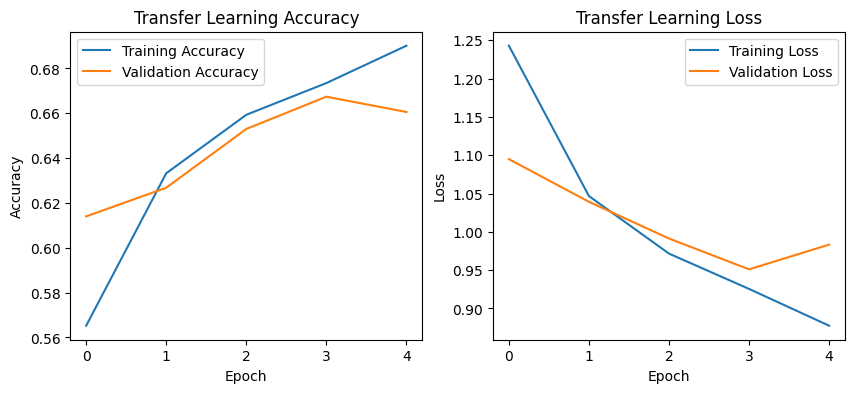

In [11]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

# Bekukan seluruh lapisan terlebih dahulu
base_model.trainable = True

# Aktifkan (unfreeze) hanya 2 lapisan terakhir dari base_model
for layer in base_model.layers[:-2]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

D6

313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 409ms/step
              precision    recall  f1-score   support

           0       0.59      0.82      0.69      1000
           1       0.76      0.75      0.76      1000
           2       0.57      0.59      0.58      1000
           3       0.58      0.32      0.41      1000
           4       0.69      0.47      0.55      1000
           5       0.53      0.64      0.58      1000
           6       0.64      0.75      0.69      1000
           7       0.81      0.64      0.72      1000
           8       0.75      0.79      0.77      1000
           9       0.65      0.76      0.70      1000

    accuracy                           0.65     10000
   macro avg       0.66      0.65      0.64     10000
weighted avg       0.66      0.65      0.64     10000



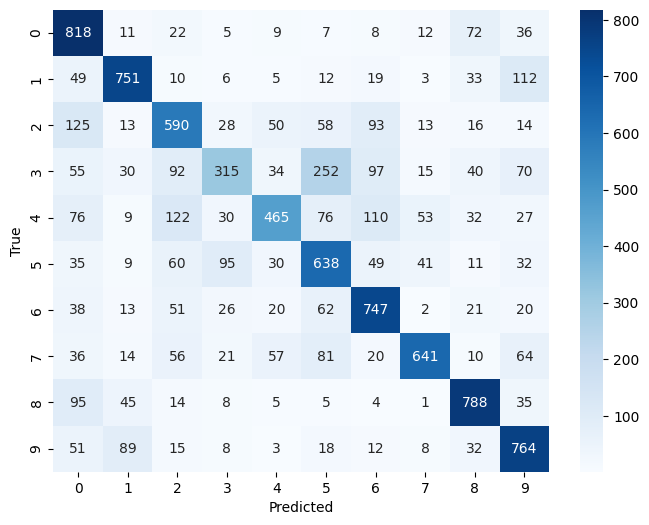

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [22]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap (gaya MNIST)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8 # ambang adaptif sederhana
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w) // 2, (28 - h) // 2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0

    # Tambah channel dim (28,28,1)
    arr = arr[..., None]
    return canvas, arr

Saving 3.png to 3.png
Saving 7.png to 7.png
Saving 8.png to 8.png


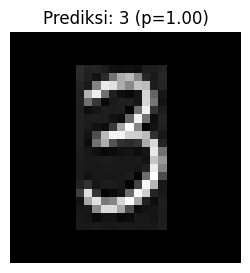

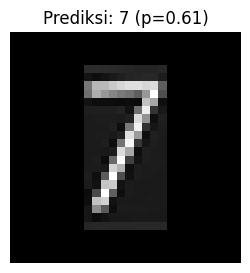

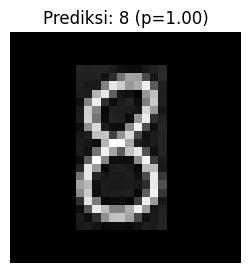


Rekap Hasil Prediksi Setelah Diperbaiki:
- File: 3.png -> Prediksi Angka: 3 (Probabilitas: 0.999)
- File: 7.png -> Prediksi Angka: 7 (Probabilitas: 0.610)
- File: 8.png -> Prediksi Angka: 8 (Probabilitas: 0.998)


In [23]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)

    # 1) Konversi ke Grayscale & Autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    # 2) Invert jika latar belakang terang (kertas putih jadi hitam, angka jadi putih)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # 3) Binarisasi sederhana untuk mendeteksi batas angka (bounding box)
    thr = np.mean(arr) * 0.7
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # 4) Ubah ukuran agar proporsional (menjaga aspect ratio agar tidak gepeng) max 20x20
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # 5) Tempel persis di tengah kanvas hitam berukuran 28x28
    canvas = Image.new('L', (28, 28), color=0)
    paste_x = (28 - w) // 2
    paste_y = (28 - h) // 2
    canvas.paste(img, (paste_x, paste_y))

    # 6) Normalisasi ke [0,1] dan tambah dimensi channel
    x = np.array(canvas).astype('float32') / 255.0
    x = x[..., None]

    # 7) Prediksi dengan model CNN
    x_batch = np.expand_dims(x, axis=0)
    probs = model.predict(x_batch, verbose=0)[0]
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))
    results.append((fname, pred, conf))

    # Tampilkan hasil gambar yang sudah proporsional
    plt.figure(figsize=(3,3))
    plt.imshow(canvas, cmap='gray')
    plt.title(f"Prediksi: {pred} (p={conf:.2f})")
    plt.axis('off')
    plt.show()

# Rekap hasil
print("\nRekap Hasil Prediksi Setelah Diperbaiki:")
for r in results:
    print(f"- File: {r[0]} -> Prediksi Angka: {r[1]} (Probabilitas: {r[2]:.3f})")